# Generating molecules with LACAN
LACAN has several methods for generating molecules. 
The most straightforward method is based on fragmenting and recombining molecules. LACAN is then used to filter out some of the more unlikely recombinations. LACAN comes provided with a corpus of ChEMBL derived fragments, which can be found in `data/rls.csv`.
The fragmentation rules are based on cutting bonds that are between two atoms of which at least one atom is in a ring, whereas the  bond is not in a ring. The resulting fragments can then be divided into 3 categories: "rings" which are cyclic structures with one or more connection point, linkers with two or more connection points, and substituents with exactly one connection point. These are randomly recombined until all connection points are satisfied.

## Generating random molecules
the function `generate_filtered_molecules` can
be used to generate random molecules purely based on the available
fragment library.

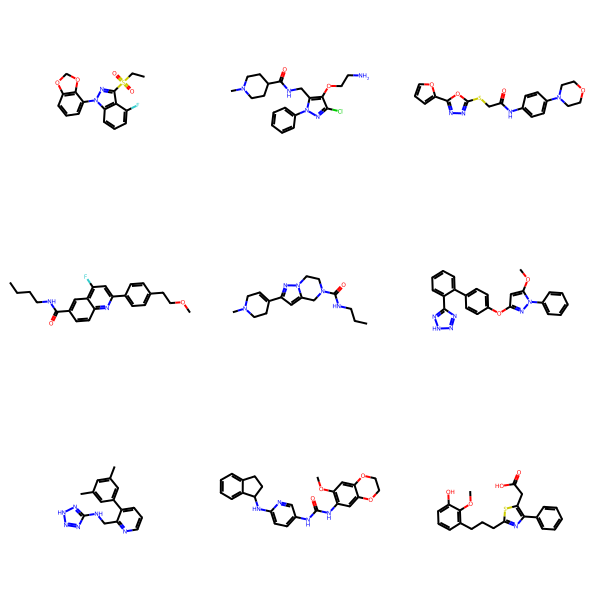

In [10]:
# import lacan and rdkit stuff
from rdkit import Chem
from rdkit.Chem import Draw
from lacan import lacan
from lacan import gen
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.drawMolsSameScale=False

# load lacan profile
p = lacan.load_profile("chembl")
# generate molecules
ms = gen.generate_filtered_molecules(n_jobs=-1,
                                     n_molecules=9,
                                     profile=p,
                                     seed=456,
                                     min_atoms=20)
# display the molecules
d = Draw.MolsToGridImage(ms,molsPerRow=3)
display(d)

## Generating random molecules based on custom compounds
Similarly to the use of transfer learning in modern molecular generator, it is possible to change the fragment corpus to generate molecules that are closer to a reference set. A simple example is shown below using Dopamine receptor D3 binders.

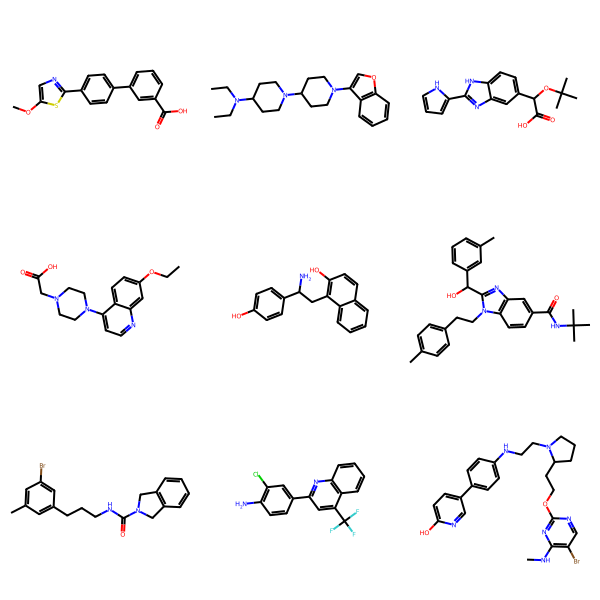

In [22]:
# load d3 binders
mols = [m for m in Chem.SmilesMolSupplier("../data/d3_actives.csv")]
# generate new fragment corpus on the fly
new_corp = gen.get_corpus_from_mols(mols,ratio=1)
# use new corpus for random generation
# generate molecules
ms = gen.generate_filtered_molecules(n_jobs=-1,
                                     n_molecules=9,
                                     profile=p,
                                     seed=456,
                                     min_atoms=20,
                                     fragcorpus=new_corp)
# display the molecules
d = Draw.MolsToGridImage(ms,molsPerRow=3)
display(d)

## Generating molecules towards some goal
LACAN makes it possible to do perform standard genetic operations
on molecules (mutations, crossover) while keeping unusual structures under control. This means these operations can be used for an evolutionary strategy, where a population undergoes several rounds of mutation, recombination and selection. For this purpose, LACAN provides the function `generate_optimized_molecules`. This function needs a score to optimize, which is provided by the user as a python function that takes an array of rdkit molecules as the input and a score as the output.
Below we build a simple toy RF-ECFP model for D3 ligands, which we use to guide generation. Note that this takes a few minutes to run, so please be patient. The results tend to include classic motifs for this receptor like arylpiperazines.

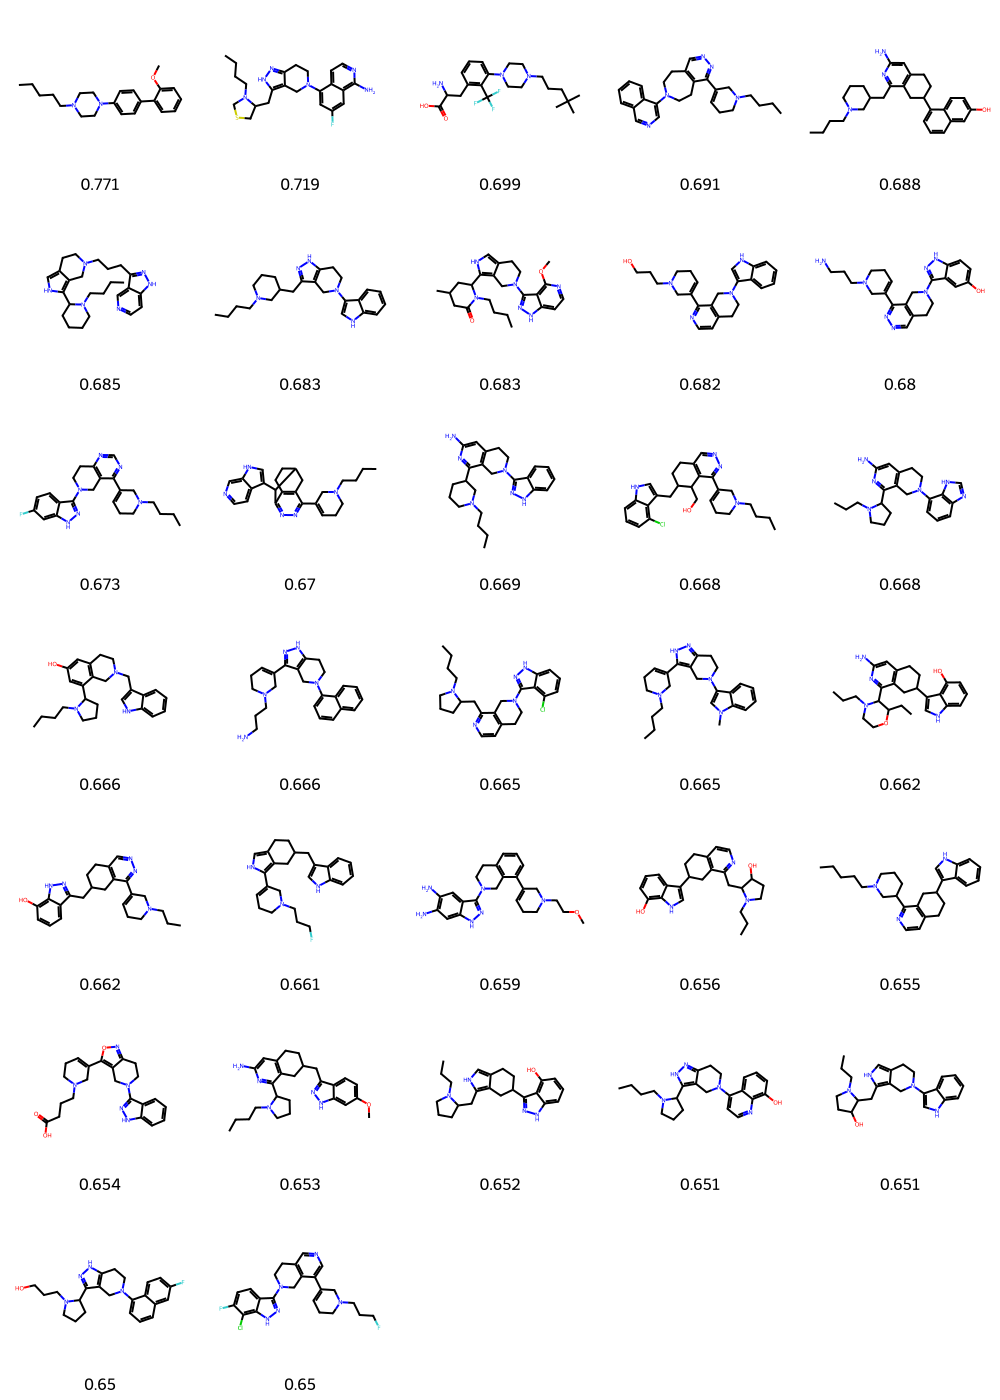

In [23]:
# building an overfitted toy model
from sklearn.ensemble import RandomForestClassifier
from rdkit.Chem import rdFingerprintGenerator
MFPGEN = rdFingerprintGenerator.GetMorganGenerator(2,fpSize=1024)
actives = [m for m in Chem.SmilesMolSupplier("../data/d3_actives.csv")]
decoys = [m for m in Chem.SmilesMolSupplier("../data/d3_decoys.csv")]
X = [MFPGEN.GetFingerprintAsNumPy(m) for m in actives+decoys]
y = [1]*len(actives)+[0]*len(decoys)
rfc = RandomForestClassifier(n_jobs=12,max_depth=10,n_estimators=100)
rfc.fit(X,y)
# we use the positive classification probability as the goal to optimize
def rfscores(mols):
    fps = [MFPGEN.GetFingerprintAsNumPy(mol) for mol in mols]
    scores = [k[1] for k in rfc.predict_proba(fps)]
    return scores
#generating new molecules
winners = gen.generate_optimized_molecules(rfscores,p,
                                           win_threshold=0.65,
                                           popsize=50,
                                           generations=10,
                                           higher_is_better=True,
                                           quiet=True,
                                           seed=456)
#sort by score and display the molecules
allc = sorted(winners,key=lambda x:-x[1])
d = Draw.MolsToGridImage([Chem.MolFromSmiles(c[0]) for c in allc],useSVG=True,molsPerRow=5,legends=[str(round(c[1],3)) for c in allc],maxMols=1000)
display(d)

In [20]:
len(winners)

5